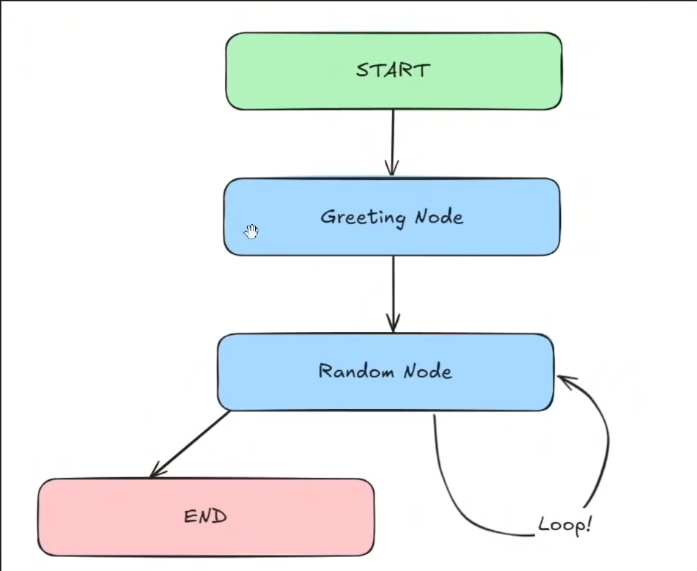

In [6]:
from langgraph.graph import StateGraph , END
import random
from typing import Dict , TypedDict , List

In [12]:
class AgentState(TypedDict):
    name : str
    number : List[str]
    counter : int
    

In [13]:
def greeting_node(state:AgentState) -> AgentState:
    """Greeting node whih says hi to the person """
    state["name"] =f"Hi there , {state["name"]}"
    state["counter"] = 0

def random_node(state:AgentState) -> AgentState:
    """Geenerated a randn b/w 0 to 10"""
    state["number"].append(random.randint(0,10))
    state["counter"] += 1

    return state

def should_continue(state:AgentState) -> AgentState:
    """FUnction to decide what to do next"""

    if state["counter"] < 5:
        print("ENTERING LOOP" , state)["counter"]
        return "loop"
    
    else:
        return "exit"

In [14]:
#greeting -> random*5 -> END

In [15]:
g = StateGraph(AgentState)

g.add_node("greeting" , greeting_node)
g.add_node("random" , random_node)
g.add_edge("greeting" , "random")

g.add_conditional_edges(
    "random",
    should_continue,
    {
        "loop" : "random",
        "exit" : END
    }
)

g.set_entry_point("greeting")
app = g.compile()

In [16]:
app.invoke({"name" : "Auroirum" , "number":[], "counter":-100})

ENTERING LOOP {'name': 'Auroirum', 'number': [0], 'counter': -99}


TypeError: 'NoneType' object is not subscriptable